# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Load the raw dataset

In [2]:
data_path = Path("../data/raw/RELIANCE.csv")
df = pd.read_csv(data_path)
df.head()

,index,Date,Adj Close,Close,High,Low,Open,Volume
0,0,2015-01-01,189.125381,202.959000,203.896194,201.987518,202.593277,2963643
1,1,2015-01-02,188.624817,202.421829,204.821960,202.136108,203.004715,7331366
2,2,2015-01-05,186.558685,200.204575,203.644760,199.804550,202.296112,10103941
3,3,2015-01-06,178.091827,191.118393,199.553116,190.181198,198.867371,18627980
4,4,2015-01-07,181.968475,195.278610,196.307236,191.324127,191.346985,20720312


Know about data range & Stats

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

print("Start:", df["Date"].min())
print("End:", df["Date"].max())
print("Trading days:", len(df))

Start: 2015-01-01 00:00:00
End: 2026-10-08 00:00:00
Trading days: 2911


In [14]:
df[["Open", "High", "Low", "Close", "Volume", "Return"]].describe()

,Open,High,Low,Close,Volume,Return
count,2911.000000,2911.000000,2911.000000,2911.000000,2.911000e+03,2910.000000
mean,839.442097,847.645195,830.870371,838.919438,1.755832e+07,0.000747
std,448.989172,452.546138,445.259063,448.750454,1.288010e+07,0.016907
min,186.661026,186.912460,182.055069,185.323807,0.000000e+00,-0.131539
25%,417.998627,421.667389,413.735565,416.970016,1.021879e+07,-0.008587
50%,924.845703,934.537170,914.692688,921.638245,1.405430e+07,0.000517
75%,1229.971619,1241.200012,1220.000000,1229.739929,2.022655e+07,0.009380
max,1604.449951,1611.800049,1585.500000,1600.900024,1.426834e+08,0.147180


Closing price over time

The closing price shows the long-term movement of the stock.

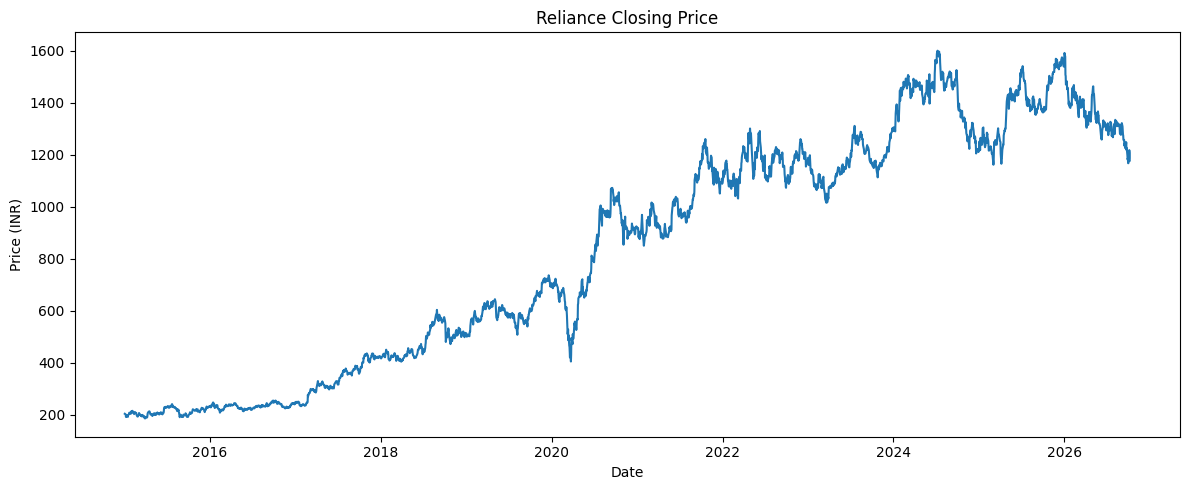

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.xticks()
plt.tight_layout()
plt.show()

The closing price shows a clear long-term upward trend, with several periods of sharp increases and declines.

Price fluctuations become larger during some periods, indicating changing market volatility.

Trading volume over time

Volume shows the number of shares traded during each trading day.

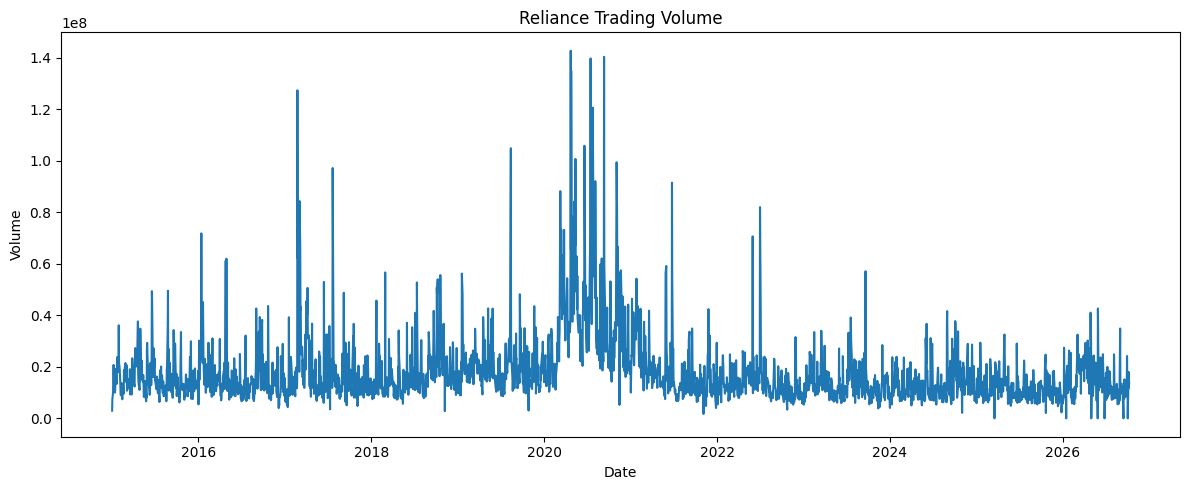

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("Reliance Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks()
plt.tight_layout()
plt.show()

Trading volume varies considerably over time, with occasional large spikes. 

The largest concentration of volume spikes appears around 2020,indicating periods of unusually high trading activity.

Calculate daily returns

Daily return measures the percentage change in closing price between consecutive trading days.

In [7]:
df["Return"] = df["Close"].pct_change()
df[["Date", "Close", "Return"]].head()

,Date,Close,Return
0,2015-01-01,202.959000,NaN
1,2015-01-02,202.421829,-0.002647
2,2015-01-05,200.204575,-0.010954
3,2015-01-06,191.118393,-0.045384
4,2015-01-07,195.278610,0.021768


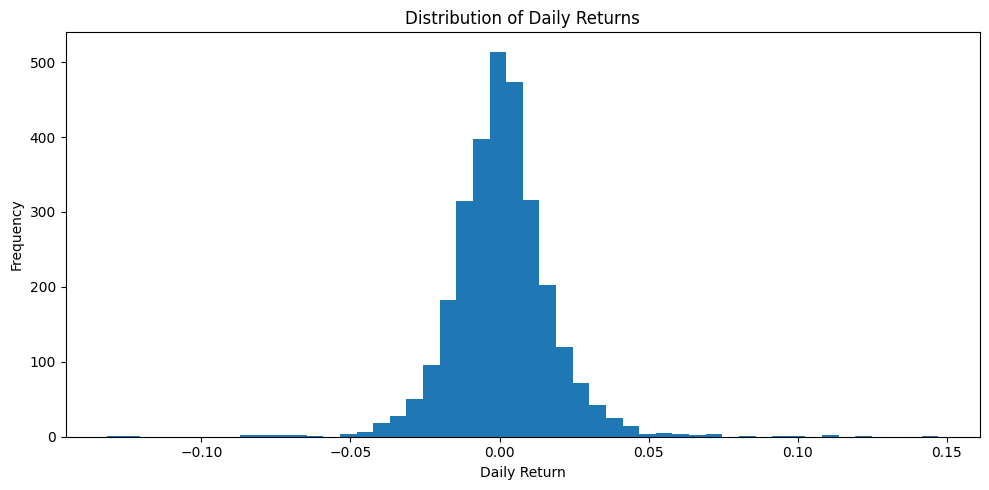

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df["Return"].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Daily returns are concentrated around zero,with most observations showing relatively small price changes. 

The distribution has long tails,indicating occasional unusually large positive or negative returns.

Moving averages

Moving averages smooth short-term fluctuations and help reveal the underlying price trend.

In [9]:
df["MA5"] = df["Close"].rolling(window=5).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()

df[["Date", "Close", "MA5", "MA20"]].tail()

,Date,Close,MA5,MA20
2906,2026-10-02,1167.699951,1180.399976,1235.050000
2907,2026-10-05,1186.400024,1178.159985,1228.895001
2908,2026-10-06,1218.000000,1185.359985,1225.050000
2909,2026-10-07,1207.699951,1189.499976,1221.484998
2910,2026-10-08,1178.000000,1191.559985,1216.684998


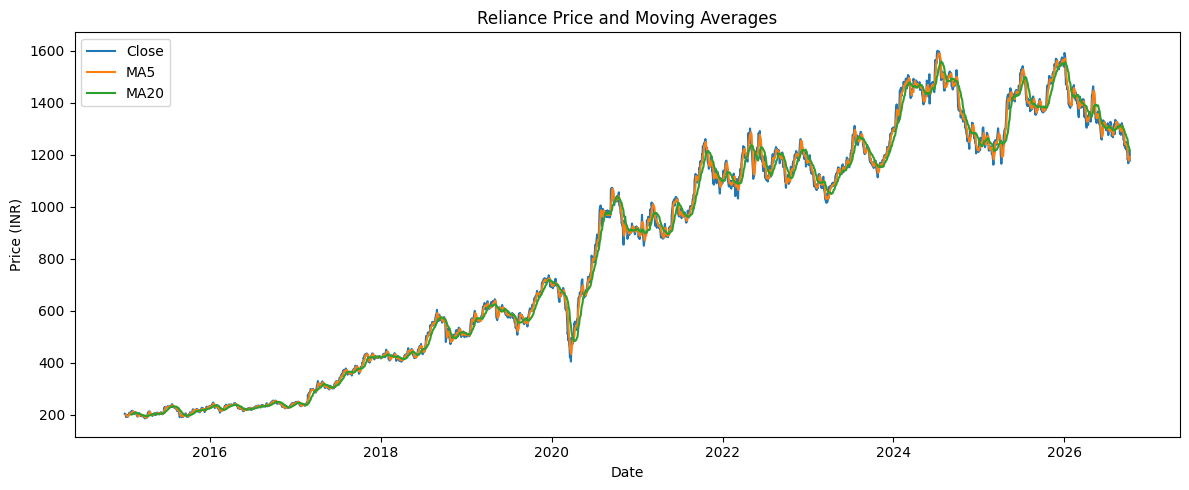

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA5"], label="MA5")
plt.plot(df["Date"], df["MA20"], label="MA20")
plt.title("Reliance Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.xticks()
plt.tight_layout()
plt.show()

The 5-day and 20-day moving averages follow the overall closing-price trend while smoothing short-term fluctuations.

The 5-day moving average responds more quickly to price changes than the 20-day moving average.

Rolling volatility

Rolling standard deviation helps measure how much daily returns fluctuate over time.

In [12]:
df["Volatility20"] = df["Return"].rolling(window=20).std()
df[["Date", "Return", "Volatility20"]].tail()

,Date,Return,Volatility20
2906,2026-10-02,0.000000,0.010869
2907,2026-10-05,0.016014,0.011902
2908,2026-10-06,0.026635,0.013711
2909,2026-10-07,-0.008457,0.013601
2910,2026-10-08,-0.024592,0.014451


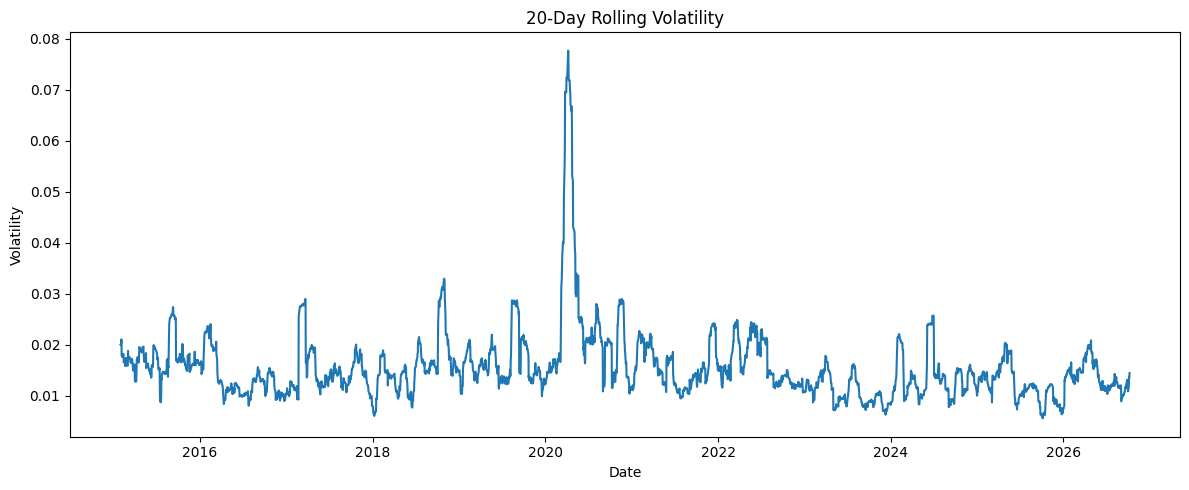

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Volatility20"])
plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks()
plt.tight_layout()
plt.show()

Rolling volatility changes substantially over time. 

A major volatility spike is visible around 2020,while volatility remains comparatively lower during several later periods.